# Predicting Online Purchase Intention from Web Session Behaviour

This notebook investigates whether e-commerce browsing sessions can be classified as purchase or non-purchase sessions using supervised machine learning.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# A fixed random state is used so that the train/test split and model results are reproducible.
RANDOM_STATE = 42

## Initial data examination

In [6]:
df = pd.read_csv("../data/online_shoppers_intention.csv")
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


The first rows show that each record represents one online shopping session. The target variable is `Revenue`, which shows whether the session ended in a purchase.

The input features describe browsing behaviour, timing and visitor/session information. These include page counts, page durations, rates such as `BounceRates` and `ExitRates`, `PageValues`, `Month`, `VisitorType`, `Weekend` and coded technical features such as `Browser`, `Region` and `TrafficType`.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

The `df.info()` output shows that the dataset has 12,330 rows and 18 columns. All columns have 12,330 non-null values, so there are no missing values shown at this stage.

The data contains a mixture of integers, floats, strings and Boolean values. This means preprocessing will be needed before modelling, especially for categorical variables and Boolean values.

In [8]:
summary_checks = pd.DataFrame({
    "rows": [df.shape[0]],
    "columns": [df.shape[1]],
    "duplicate_rows": [df.duplicated().sum()],
    "missing_values_total": [df.isnull().sum().sum()]
})

summary_checks

,rows,columns,duplicate_rows,missing_values_total
0,12330,18,125,0


The dataset has 12,330 rows and 18 columns, with no missing values.

There are 125 duplicate rows. I will not remove them automatically because this is session data, and different sessions may have the same recorded behaviour.

In [9]:
revenue_summary = pd.DataFrame({
    "count": df["Revenue"].value_counts(),
    "percentage": df["Revenue"].value_counts(normalize=True) * 100
})

revenue_summary

,count,percentage
Revenue,,
False,10422,84.525547
True,1908,15.474453


The `Revenue` summary shows a clear class imbalance. Most sessions did not end in a purchase.

This matters because a model could get a decent accuracy by mostly predicting `False`. I will therefore use precision, recall, F1-score and a confusion matrix later, not just accuracy.

Next, I examine the numerical feature distributions to understand the scale and spread of the input variables.

In [10]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


The numerical columns have quite different ranges. For example, duration and page-count columns are much larger than rate columns such as `BounceRates` and `ExitRates`.

This means scaling may be useful later for models such as logistic regression or k-nearest neighbours. Tree-based models are less affected by scaling.

In [11]:
categorical_cols = ["Month", "VisitorType", "Weekend", "OperatingSystems", "Browser", "Region", "TrafficType"]

categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_cols].nunique(),
    "most_common_value": df[categorical_cols].mode().iloc[0],
    "most_common_count": [df[col].value_counts().iloc[0] for col in categorical_cols]
})

categorical_summary

,unique_values,most_common_value,most_common_count
Month,10,May,3364
VisitorType,3,Returning_Visitor,10551
Weekend,2,False,9462
OperatingSystems,8,2,6601
Browser,13,2,7961
Region,9,1,4780
TrafficType,20,2,3913


This table shows the number of unique values in each categorical or coded feature.

These columns will need encoding before modelling, especially `Month`, `VisitorType`, `OperatingSystems`, `Browser`, `Region` and `TrafficType`.

In [12]:
df.groupby("Revenue")[["PageValues", "BounceRates", "ExitRates", "ProductRelated", "ProductRelated_Duration"]].mean()

,PageValues,BounceRates,ExitRates,ProductRelated,ProductRelated_Duration
Revenue,,,,,
False,1.975998,0.025317,0.047378,28.714642,1069.987809
True,27.264518,0.005117,0.019555,48.210168,1876.209615


The grouped averages show clear differences between purchase and non-purchase sessions. Purchase sessions have much higher average `PageValues`, more `ProductRelated` page visits, longer `ProductRelated_Duration`, lower `BounceRates` and lower `ExitRates`.

This suggests that browsing depth and page value may be useful predictors. I will check this later using feature importance and model results.

## Exploratory visualisation

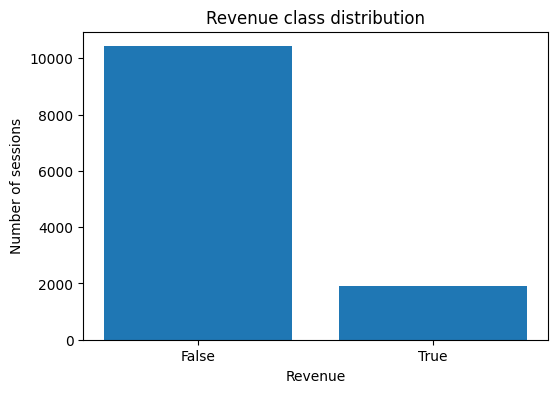

In [13]:
revenue_counts = df["Revenue"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(revenue_counts.index.astype(str), revenue_counts.values)
plt.title("Revenue class distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of sessions")
plt.show()

The chart shows a clear class imbalance. Most sessions did not end in a purchase.

Because of this, accuracy on its own will not be enough. I will also use precision, recall, F1-score and a confusion matrix later.

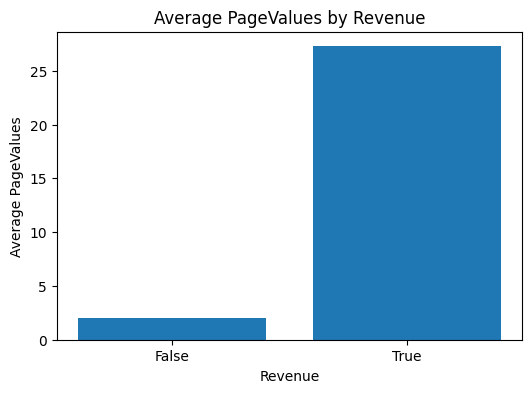

In [14]:
pagevalues_mean = df.groupby("Revenue")["PageValues"].mean()

plt.figure(figsize=(6, 4))
plt.bar(pagevalues_mean.index.astype(str), pagevalues_mean.values)
plt.title("Average PageValues by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average PageValues")
plt.show()

Purchase sessions have much higher average `PageValues`.

This suggests that `PageValues` may be useful for predicting `Revenue`. I will check this again later when comparing feature importance and model performance.

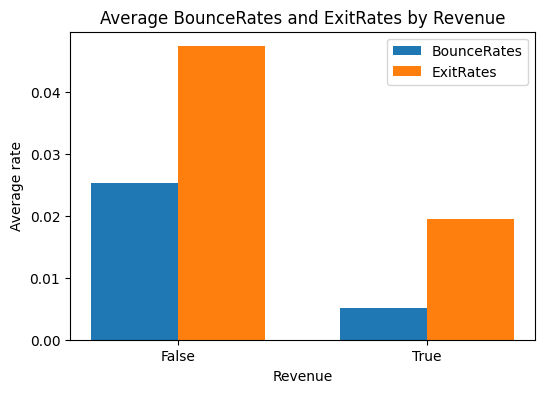

In [15]:
rate_means = df.groupby("Revenue")[["BounceRates", "ExitRates"]].mean()

x = np.arange(len(rate_means.index))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, rate_means["BounceRates"], width, label="BounceRates")
plt.bar(x + width/2, rate_means["ExitRates"], width, label="ExitRates")
plt.title("Average BounceRates and ExitRates by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average rate")
plt.xticks(x, rate_means.index.astype(str))
plt.legend()
plt.show()

Purchase sessions have lower average `BounceRates` and `ExitRates`.

`BounceRates` refers to sessions where a user enters the site and leaves without continuing to other pages. `ExitRates` refers to how often users leave from a particular page. 

Lower values for purchase sessions suggest that users who stay and continue browsing are more likely to buy, so these features may help the models separate purchase and non-purchase sessions.

## Feature and target preparation

In [16]:
# Separate the input features from the target variable
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (12330, 17)
Target data shape: (12330,)


I split the dataset into `X` and `y`. `X` contains the input features, and `y` contains the target variable, `Revenue`.

This gives 17 features for each session and one target value to predict.

In [17]:
# Check the target balance before splitting the data
target_balance = pd.DataFrame({
    "count": y.value_counts(),
    "percentage": y.value_counts(normalize=True) * 100
})

target_balance

,count,percentage
Revenue,,
False,10422,84.525547
True,1908,15.474453


The target balance is checked again before splitting the data.

Because the classes are imbalanced, I will use a stratified train-test split so that the training and test sets keep a similar balance of purchase and non-purchase sessions.

In [18]:
# Set up the column groups for preprocessing
categorical_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

numerical_features = [col for col in X.columns if col not in categorical_features]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


The columns are separated into categorical and numerical features.

The categorical list includes text columns, one Boolean value and coded category columns. The remaining columns are treated as numerical browsing-behaviour features.

`Weekend` is included with the categorical features because it describes the type of session rather than measuring a continuous value. Since it simply indicates whether the visit happened on a weekend or not, it makes sense to treat it like the other categorical variables. Similarly, features such as `OperatingSystems`, `Browser`, `Region`, and `TrafficType` are treated as categorical because their numbers are just labels for different groups, not values with a meaningful order.

In [19]:
# Split the data with an 80/20 train/test split
# Stratify keeps the Revenue balance similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training features: (9864, 17)
Test features: (2466, 17)
Training target: (9864,)
Test target: (2466,)


The data is split into training and test sets. The training set will be used to fit the models, while the test set will be kept back for evaluation.

An 80/20 train-test split is used so that most of the dataset is available for model training, while still keeping a separate unseen test set for final evaluation. The split uses `stratify=y` because the target variable is imbalanced, with only about 15.5% of sessions resulting in a purchase. Stratification keeps this class balance similar in both the training and test sets, which makes the evaluation fairer and reduces the chance that the minority purchase class is under-represented in either split.

In [20]:
# Check that the class balance is similar after the split
split_balance = pd.DataFrame({
    "train_percentage": y_train.value_counts(normalize=True) * 100,
    "test_percentage": y_test.value_counts(normalize=True) * 100
})

split_balance

,train_percentage,test_percentage
Revenue,,
False,84.529603,84.509327
True,15.470397,15.490673


`split_balance` confirms that stratification successfully maintained consistent class proportions between the training and testing sets.

# Preprocessing setup

In [21]:
# Scale numbers and one-hot encode categories
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    sparse_threshold=0
)

print(preprocessor)

ColumnTransformer(sparse_threshold=0,
                  transformers=[('num', StandardScaler(),
                                 ['Administrative', 'Administrative_Duration',
                                  'Informational', 'Informational_Duration',
                                  'ProductRelated', 'ProductRelated_Duration',
                                  'BounceRates', 'ExitRates', 'PageValues',
                                  'SpecialDay']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Month', 'VisitorType', 'Weekend',
                                  'OperatingSystems', 'Browser', 'Region',
                                  'TrafficType'])])


The preprocessor applies different steps to different column types.

The numerical columns are scaled with `StandardScaler`, and the categorical columns are converted with `OneHotEncoder`. This prepares the data for models that need numerical input.

## Feature Selection

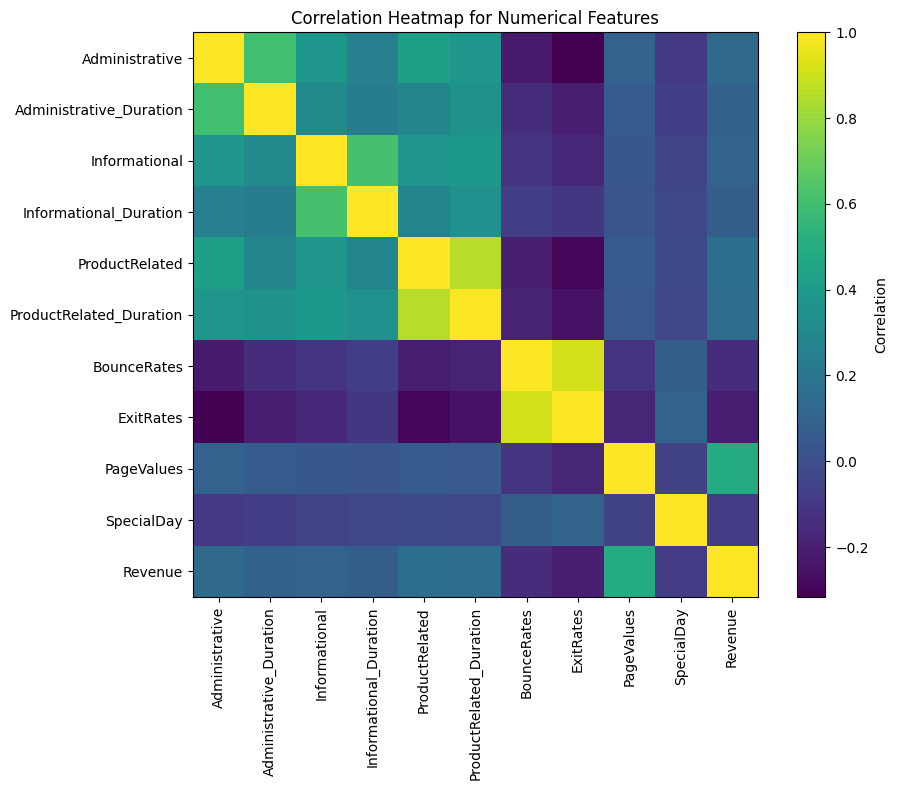

In [22]:
# Correlation gives a simple filter-style check for numerical features.
# Revenue is converted to 0/1 so it can be included in the correlation table.
numeric_corr_df = df[numerical_features + ["Revenue"]].copy()
numeric_corr_df["Revenue"] = numeric_corr_df["Revenue"].astype(int)

corr_matrix = numeric_corr_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()

In the heatmap, brighter colours show stronger positive correlations, while darker colours show negative correlations. The diagonal is always strongest because each feature is perfectly correlated with itself.In the heatmap, brighter colours show stronger positive correlations, while darker colours show negative correlations. This makes it easier to see that `PageValues` has the clearest positive link with `Revenue`, while `ExitRates` and `BounceRates` move in the opposite direction.

In [23]:
revenue_correlations = (
    corr_matrix["Revenue"]
    .drop("Revenue")
    .sort_values(key=abs, ascending=False)
    .reset_index()
)

revenue_correlations.columns = ["feature", "correlation_with_revenue"]
revenue_correlations

,feature,correlation_with_revenue
0,PageValues,0.492569
1,ExitRates,-0.207071
2,ProductRelated,0.158538
3,ProductRelated_Duration,0.152373
4,BounceRates,-0.150673
5,Administrative,0.138917
6,Informational,0.095200
7,Administrative_Duration,0.093587
8,SpecialDay,-0.082305
9,Informational_Duration,0.070345


The correlation check reinforces that `PageValues` has the strongest positive relationship with `Revenue`, with a correlation of 0.493. `ProductRelated` and `ProductRelated_Duration` are also positively related to purchases, at 0.159 and 0.152.

`ExitRates` and `BounceRates` have negative correlations with `Revenue`, at -0.207 and -0.151. This makes sense because sessions where users leave quickly are less likely to end in a purchase.

Some features, such as `Administrative`, `Informational`, `SpecialDay` and `Informational_Duration`, show weaker direct correlations. These features may still be useful in combination with others, but their individual linear relationship with `Revenue` is weaker. Correlation is therefore used as a simple filter check, while mutual information is used next as a broader feature selection method.

## Feature Selection with Mutual Information

I will use mutual information as a filter-based feature selection method to get an initial idea of how strongly each input feature relates to the target variable. This step will be applied only to the training data so that no information from the test set is used during model development.

This step gives an independent feature-ranking method before the model-based feature importance section later in the notebook.

mutual_info_classif scores each processed feature by how much information it appears to give about the target, Revenue. A higher score means the feature has a stronger relationship with whether the session ended in a purchase.

In [24]:
from sklearn.base import clone
from sklearn.feature_selection import mutual_info_classif

# Fit a copy of the preprocessor on the training data only.
# This avoids using the test set when calculating feature selection scores.
mi_preprocessor = clone(preprocessor)

X_train_processed = mi_preprocessor.fit_transform(X_train)
processed_feature_names = mi_preprocessor.get_feature_names_out()

# Mutual information gives a filter-based score for each processed feature.
# The random_state keeps the score calculation reproducible.
mi_scores = mutual_info_classif(
    X_train_processed,
    y_train,
    random_state=RANDOM_STATE
)

mi_scores_df = (
    pd.DataFrame({
        "feature": processed_feature_names,
        "mutual_information": mi_scores
    })
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

mi_scores_df.head(15)

,feature,mutual_information
0,num__PageValues,0.171488
1,num__ExitRates,0.044069
2,num__ProductRelated_Duration,0.037681
3,num__BounceRates,0.029675
4,num__ProductRelated,0.019710
5,num__Administrative_Duration,0.019486
6,num__Administrative,0.014115
7,cat__Month_Nov,0.013364
8,num__SpecialDay,0.008251
9,cat__VisitorType_New_Visitor,0.007232


The mutual information results show that `PageValues` has the strongest relationship with `Revenue`, with a score of 0.171488. This is way higher than the next strongest features, such as `ExitRates` at 0.044069, `ProductRelated_Duration` at 0.037681 and `BounceRates` at 0.029675.

This supports the earlier analysis because these features describe session value, exit behaviour and product browsing activity, which are directly relevant to whether a session ends in a purchase.

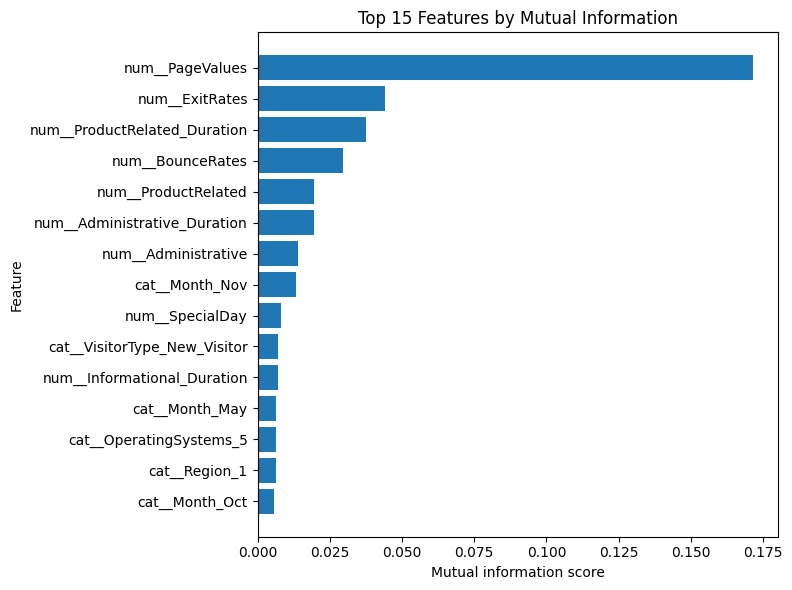

In [25]:
top_mi_features = mi_scores_df.head(15).sort_values("mutual_information")

plt.figure(figsize=(8, 6))
plt.barh(top_mi_features["feature"], top_mi_features["mutual_information"])
plt.xlabel("Mutual information score")
plt.ylabel("Feature")
plt.title("Top 15 Features by Mutual Information")
plt.tight_layout()
plt.show()

Most of the strongest features are numerical session-behaviour features (`ProductRelated`, `ProductRelated_Duration`, `Administrative`, `Administrative_Duration`, `BounceRates`, `ExitRates` and `PageValues`).

Some categorical features also appear in the top 15 after one-hot encoding, including `Month_Nov`, `VisitorType_New_Visitor`, `Month_May`, `OperatingSystems_5`, `Region_1` and `Month_Oct`. This suggests that timing and visitor type may add some useful information, but they are less important than the main behavioural features.

In [26]:
from sklearn.feature_selection import SelectKBest

# Use the top 15 processed features from mutual information.
# This selector is placed inside the pipeline so it is fitted only on the
# training folds during cross-validation.
TOP_K_FEATURES = 15

selected_feature_results = []
selected_feature_pipelines = {}

selected_feature_models = {
    "Logistic Regression selected features": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Support Vector Machine selected features": SVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Hist Gradient Boosting selected features": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "MLPClassifier selected features": MLPClassifier(
        max_iter=1000,
        random_state=RANDOM_STATE
    )
}

for model_name, model in selected_feature_models.items():
    selected_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("feature_selection", SelectKBest(
            score_func=mutual_info_classif,
            k=TOP_K_FEATURES
        )),
        ("model", model)
    ])

    selected_pipeline.fit(X_train, y_train)
    y_pred_selected = selected_pipeline.predict(X_test)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred_selected),
        "precision": precision_score(y_test, y_pred_selected, pos_label=True, zero_division=0),
        "recall": recall_score(y_test, y_pred_selected, pos_label=True, zero_division=0),
        "f1": f1_score(y_test, y_pred_selected, pos_label=True, zero_division=0)
    }

    selected_feature_results.append(results)
    selected_feature_pipelines[model_name] = selected_pipeline

selected_feature_results_df = pd.DataFrame(selected_feature_results)
selected_feature_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
2,Hist Gradient Boosting selected features,0.897810,0.707006,0.581152,0.637931
1,Support Vector Machine selected features,0.858070,0.528986,0.764398,0.625268
0,Logistic Regression selected features,0.854826,0.522305,0.735602,0.610870
3,MLPClassifier selected features,0.886861,0.672241,0.526178,0.590308


`Support Vector Machine` had the highest recall on the selected feature set, at 0.767, meaning it identified the most purchase sessions. However, its precision was lower at 0.528, so it also made more false purchase predictions.

`Logistic Regression` showed a similar pattern, with strong recall but lower precision. `MLPClassifier` performed reasonably, but it did not outperform `Hist Gradient Boosting`.

Overall, mutual information supports the later model-based feature importance results. `PageValues` is clearly the dominant feature, while exit behaviour, product browsing activity and some timing features also contribute useful information.

The selected-feature models show that a smaller feature set can keep similar performance, although the full-feature tuned `Hist Gradient Boosting` model remains slightly stronger so far.

## Candidate Machine Learning Models

This project uses supervised machine learning because the dataset contains labelled examples. Each session has a known target value, `Revenue`, showing whether the session ended in a purchase. The task is therefore a binary classification problem.

Several candidate classification algorithms are tested so that different modelling approaches can be compared. `Logistic Regression` is included as an interpretable linear baseline. `Decision Tree` and `Random Forest` are included because tree-based models can capture non-linear relationships and interactions between features. `Gradient Boosting` and `Hist Gradient Boosting` are included because boosting methods often perform well on structured tabular datasets. `Support Vector Machine` is included because it can work well for classification after scaling. `K-Nearest Neighbours` is included as a distance-based baseline, while `MLPClassifier` is included as a neural network comparison.

This gives a mix of linear, tree-based, ensemble, distance-based, kernel-based and neural network methods. Comparing these models helps avoid choosing a final model based on one modelling assumption only.

## Baseline model comparison

I will now try several baseline classification models using the same train-test split and the same preprocessing steps.

Because the target is imbalanced, accuracy could be misleading. I will still record accuracy, but I will focus more on F1-score, recall, precision and the confusion matrix.

The baseline models are first trained using default or lightly adjusted settings. This gives an initial comparison before tuning. For models that support it cleanly, `class_weight="balanced"` is used because the target variable is imbalanced and only about 15.5% of sessions resulted in a purchase. The main comparison metric is F1-score, because it balances precision and recall and is more informative than accuracy alone for this imbalanced classification task.

In [27]:
# Baseline models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "K-Nearest Neighbours": KNeighborsClassifier(),
    "Support Vector Machine": SVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "MLPClassifier": MLPClassifier(
        max_iter=500,
        random_state=RANDOM_STATE
    )
}

`class_weight="balanced"` is used for models where it works well, such as Logistic Regression, Decision Tree, Random Forest, and SVM. It helps the model pay more attention to the smaller purchase class by giving it extra weight. Since not all models handle this setting in the same way, class imbalance is also addressed through stratified splitting and by focusing on F1-score, precision, and recall instead of accuracy alone.

In [28]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    # Put the same preprocessing in front of every model
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train on the training data only
    pipeline.fit(X_train, y_train)
    
    # Predict on the test data
    y_pred = pipeline.predict(X_test)
    
    # Store the main scores
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=True, zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label=True, zero_division=0),
        "f1": f1_score(y_test, y_pred, pos_label=True, zero_division=0)
    }
    
    print("\n" + model_name)
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return results, pipeline

In [29]:
baseline_results = []
trained_pipelines = {}

for model_name, model in models.items():
    results, pipeline = evaluate_model(
        model_name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )
    
    baseline_results.append(results)
    trained_pipelines[model_name] = pipeline


Logistic Regression
Confusion matrix:
[[1790  294]
 [  98  284]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.86      0.90      2084
        True       0.49      0.74      0.59       382

    accuracy                           0.84      2466
   macro avg       0.72      0.80      0.75      2466
weighted avg       0.88      0.84      0.85      2466


Decision Tree
Confusion matrix:
[[1899  185]
 [ 183  199]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.91      0.91      2084
        True       0.52      0.52      0.52       382

    accuracy                           0.85      2466
   macro avg       0.72      0.72      0.72      2466
weighted avg       0.85      0.85      0.85      2466


Random Forest
Confusion matrix:
[[2031   53]
 [ 207  175]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.97

/Users/garyzolty/Desktop/University/AML/aml-online-shoppers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [30]:
baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
5,Gradient Boosting,0.899027,0.709779,0.589005,0.643777
6,Hist Gradient Boosting,0.897810,0.708333,0.578534,0.636888
4,Support Vector Machine,0.865369,0.547710,0.751309,0.633554
0,Logistic Regression,0.841038,0.491349,0.743455,0.591667
2,Random Forest,0.894566,0.767544,0.458115,0.573770
7,MLPClassifier,0.869424,0.585227,0.539267,0.561308
1,Decision Tree,0.850770,0.518229,0.520942,0.519582
3,K-Nearest Neighbours,0.876723,0.682243,0.382199,0.489933


The baseline comparison shows that the models behave quite differently on the purchase class.

Gradient Boosting has the best F1-score for the True class, at about 0.64, and the highest accuracy at about 0.90. Its precision is about 0.71 and recall is about 0.59, so it gives the strongest overall balance in the baseline comparison.

Hist Gradient Boosting performs almost the same as Gradient Boosting, with accuracy of 0.898 and an F1-score of 0.637 for the True class. Its precision is 0.708 and recall is 0.579. This shows that the histogram-based version is a useful alternative, but in this baseline test it does not quite improve on the standard Gradient Boosting model.

Support Vector Machine has the highest recall for the purchase class, at about 0.75, which means it finds the most actual purchase sessions. However, its precision is lower than Gradient Boosting, so it also makes more false purchase predictions.

Random Forest has the highest precision for the purchase class, at about 0.76, but recall is much lower at about 0.46. This means it gives fewer false purchase predictions, but misses more real purchases.

Logistic Regression remains a useful baseline due to it's good recall, but its precision is lower. Decision Tree and K-Nearest Neighbours are weaker overall on F1-score. MLPClassifier performs reasonably, but it gives a convergence warning, so it needs more tuning before being judged properly.

Based on this first comparison, Gradient Boosting, Hist Gradient Boosting, Support Vector Machine, Random Forest and Logistic Regression look most worth continuing with. Gradient Boosting has the best F1-score, Hist Gradient Boosting gives a very similar result and may be faster to tune, SVM and Logistic Regression have strong recall, and Random Forest has strong precision.
MLPClassifier gives a reasonable result. Although its baseline result did not outperform the best classical models and it produced a convergence warning, it is still useful as a comparison because neural networks are a different model family. This allows the project to compare linear, kernel-based, tree-based ensemble and neural network approaches.

## Feature Importance Analysis

I want to look at feature importance before tuning, because it helps show which inputs the strongest baseline model is using most.

This may help decide whether a smaller feature set is worth testing later, but I will not remove features automatically just because they have lower importance.

I will plot the feature importance from Gradient Boosting, which was the strongest baseline model by F1-score. This gives a clearer view of which features are driving the model.

In [31]:
# Get the trained Gradient Boosting pipeline
gb_pipeline = trained_pipelines["Gradient Boosting"]

# Get the fitted model and the fitted preprocessor
gb_model = gb_pipeline.named_steps["model"]
gb_preprocessor = gb_pipeline.named_steps["preprocessor"]

# Get the feature names after preprocessing
feature_names = gb_preprocessor.get_feature_names_out()

# Match each feature name with its importance score
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": gb_model.feature_importances_
})

feature_importance.sort_values(by="importance", ascending=False).head(10)

,feature,importance
8,num__PageValues,0.761713
6,num__BounceRates,0.039870
17,cat__Month_Nov,0.037841
0,num__Administrative,0.031076
7,num__ExitRates,0.029149
5,num__ProductRelated_Duration,0.027551
4,num__ProductRelated,0.023125
1,num__Administrative_Duration,0.011746
16,cat__Month_May,0.008686
3,num__Informational_Duration,0.004775


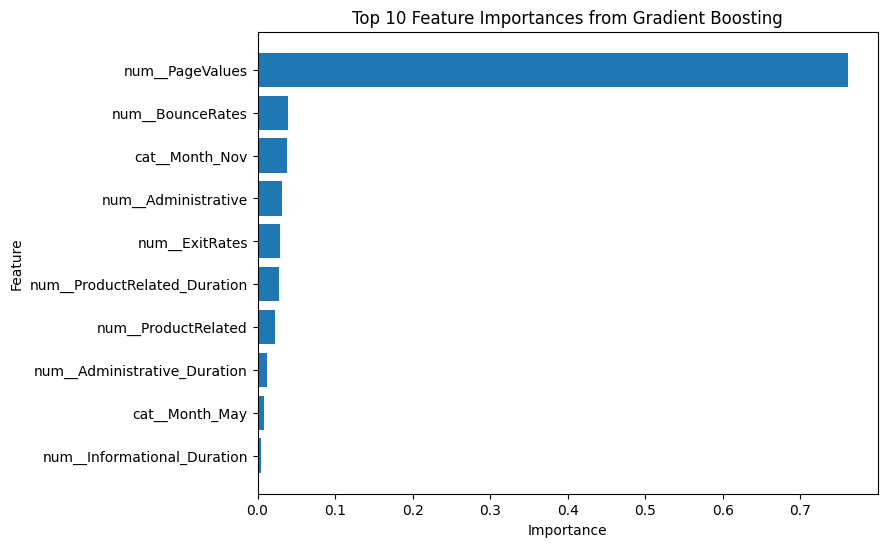

In [32]:
top_features = feature_importance.sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 10 Feature Importances from Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance plot shows that `PageValues` is by far the strongest feature in the Gradient Boosting model.

After `PageValues`, the next most important features are `BounceRates`, `Month_Nov`, `Administrative`, `ExitRates`, `ProductRelated_Duration` and `ProductRelated`. This partly supports the earlier analysis, because `BounceRates`, `ExitRates` and product-related activity all relate to how users move through the website.

`Month_Nov` being important may make sense because online shopping behaviour can change by month, especially around seasonal shopping periods. `Administrative` is also useful to note because it suggests that non-product browsing activity may still contain some signal.

One thing to note is that `PageValues` dominates the plot. I will keep it in the model because it is part of the dataset, but I should mention in the report that the model relies heavily on this feature.

## Testing Model Dependence on PageValues

The feature importance results showed that `PageValues` was by far the strongest feature in the `Gradient Boosting` model. This may be useful for prediction, but it also means the model may depend heavily on one feature. 

To test this, I will train another `Gradient Boosting` model without `PageValues` and compare the results with the original model.

In [33]:
# Create a new feature set without PageValues
X_no_pagevalues = X.drop("PageValues", axis=1)

# Update feature groups
numerical_features_no_pagevalues = [
    col for col in numerical_features if col != "PageValues"
]

categorical_features_no_pagevalues = categorical_features.copy()

# Split the data again using the same settings
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_no_pagevalues,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# Create preprocessing for the reduced feature set
preprocessor_no_pagevalues = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_no_pagevalues),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_no_pagevalues)
    ]
)

# Build the pipeline manually because this experiment uses a different preprocessor
gb_no_pagevalues_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_no_pagevalues),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

# Train on the reduced feature set
gb_no_pagevalues_pipeline.fit(X_train_np, y_train_np)

# Predict on the test data
y_pred_np = gb_no_pagevalues_pipeline.predict(X_test_np)

# Store the main scores
gb_no_pagevalues_results = {
    "model": "Gradient Boosting without PageValues",
    "accuracy": accuracy_score(y_test_np, y_pred_np),
    "precision": precision_score(y_test_np, y_pred_np, pos_label=True, zero_division=0),
    "recall": recall_score(y_test_np, y_pred_np, pos_label=True, zero_division=0),
    "f1": f1_score(y_test_np, y_pred_np, pos_label=True, zero_division=0)
}

print("\nGradient Boosting without PageValues")
print("Confusion matrix:")
print(confusion_matrix(y_test_np, y_pred_np))

print("\nClassification report:")
print(classification_report(y_test_np, y_pred_np, zero_division=0))

gb_no_pagevalues_results


Gradient Boosting without PageValues
Confusion matrix:
[[2052   32]
 [ 356   26]]

Classification report:
              precision    recall  f1-score   support

       False       0.85      0.98      0.91      2084
        True       0.45      0.07      0.12       382

    accuracy                           0.84      2466
   macro avg       0.65      0.53      0.52      2466
weighted avg       0.79      0.84      0.79      2466



{'model': 'Gradient Boosting without PageValues',
 'accuracy': 0.8426601784266018,
 'precision': 0.4482758620689655,
 'recall': 0.06806282722513089,
 'f1': 0.11818181818181818}

Removing `PageValues` caused a major drop in performance for the purchase class. The original `Gradient Boosting` model had an F1-score of 0.644 for `Revenue=True`, but without `PageValues` this dropped to 0.118. Recall for purchase sessions also fell dramatically to 0.068, as the model only identified 26 out of 382 actual purchase sessions.

The confusion matrix shows that the model became very conservative after removing `PageValues`. It correctly predicted most non-purchase sessions, with 2052 true negatives and only 32 false positives, but it missed 356 purchase sessions. This means the model still achieved 0.843 accuracy, but that seemingly high accuracy is misleading because the dataset is imbalanced and the model performs poorly on the minority purchase class.

This testing confirms that `PageValues` is a very strong predictor for this dataset. It should be kept in the final model, but the report should mention that the model depends heavily on this feature.

## Model Tuning and Refinement

After comparing the baseline models, the strongest or most informative candidates are tuned. Tuning is focused on models that either achieved strong baseline F1-score or showed a useful precision-recall trade-off. `Gradient Boosting` and `Hist Gradient Boosting` are tuned because they had the strongest baseline F1-scores. `Support Vector Machine` is tuned because it achieved high recall. `Logistic Regression` is tuned lightly because it provides an interpretable comparison model. `MLPClassifier` is also tuned because it gives a neural network comparison, but its settings need refinement due to the convergence warning.

`RandomizedSearchCV` is used for tuning rather than a full grid search. This is a practical choice because several models and parameter combinations are being tested, and random search can explore useful configurations with lower runtime than testing every possible combination. The searches use 5-fold cross-validation on the training data and `scoring="f1"` so that each configuration is compared using a metric that reflects both precision and recall.

## Tuning Gradient Boosting

I will tune `Gradient Boosting` first because it has the best baseline F1-score for the purchase class. I will use a small parameter search rather than a very large grid, so that the tuning process will be manageable and can run locally. The search will use F1-score as the main scoring metric for the reasons explained above.

In [34]:
from sklearn.model_selection import RandomizedSearchCV

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

"""
I chose these parameters because they control the main ways a Gradient Boosting model can become more or less complex. 
`n_estimators` and `learning_rate` control how many boosting stages are used and how strongly each stage affects the final model. 
`max_depth` controls how complex each individual tree can be, while `min_samples_leaf` can help reduce overfitting by stopping leaves from
becoming too small. I used a small search space first so that tuning stayed manageable and could be expanded later if needed [2].
[2] Scikit-learn developers, “GradientBoostingClassifier,” Scikit-learn documentation. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html. [Accessed: 3-Jun-2026].
"""
gb_param_grid = {
    # Number of boosting stages to build
    "model__n_estimators": [100, 200],
    # Controls how strongly each new tree contributes
    # Scikit-learn notes a trade-off between learning_rate and n_estimators [2]
    "model__learning_rate": [0.05, 0.1],
    # Controls the depth of each individual tree
    "model__max_depth": [2, 3],
    # A slightly higher value can smooth the model and reduce overfitting
    "model__min_samples_leaf": [1, 2]
}

# RandomizedSearchCV tests a limited number of parameter combinations using cross-validation, rather than exhaustively testing every combination [3].
# [3] Scikit-learn developers, “RandomizedSearchCV,” Scikit-learn documentation. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html. [Accessed: 3-Jun-2026].
gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_grid,
    n_iter=6,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Fit the search on the training data only
gb_search.fit(X_train, y_train)

print("Best parameters:")
print(gb_search.best_params_)

print("Best cross-validation F1-score:")
print(gb_search.best_score_)

Best parameters:
{'model__n_estimators': 100, 'model__min_samples_leaf': 2, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Best cross-validation F1-score:
0.6614963923916196


In [35]:
gb_tuned_pred = gb_search.predict(X_test)

gb_tuned_results = {
    "model": "Tuned Gradient Boosting",
    "accuracy": accuracy_score(y_test, gb_tuned_pred),
    "precision": precision_score(y_test, gb_tuned_pred, pos_label=True, zero_division=0),
    "recall": recall_score(y_test, gb_tuned_pred, pos_label=True, zero_division=0),
    "f1": f1_score(y_test, gb_tuned_pred, pos_label=True, zero_division=0)
}

print("\nTuned Gradient Boosting")
print("Confusion matrix:")
print(confusion_matrix(y_test, gb_tuned_pred))

print("\nClassification report:")
print(classification_report(y_test, gb_tuned_pred, zero_division=0))

gb_tuned_results


Tuned Gradient Boosting
Confusion matrix:
[[1995   89]
 [ 157  225]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.96      0.94      2084
        True       0.72      0.59      0.65       382

    accuracy                           0.90      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.90      0.90      2466



{'model': 'Tuned Gradient Boosting',
 'accuracy': 0.9002433090024331,
 'precision': 0.7165605095541401,
 'recall': 0.5890052356020943,
 'f1': 0.646551724137931}

The tuned `Gradient Boosting` model selected 100 boosting stages, a minimum leaf size of 2, a maximum tree depth of 3 and a learning rate of 0.1. This is quite close to the default model, but with a slightly higher `min_samples_leaf`, which can help reduce overfitting by stopping very small leaf nodes.

The tuned model gave a small improvement over the original baseline `Gradient Boosting` result. The baseline model had an F1-score of 0.644 for the `Revenue=True` class, while the tuned model achieved about 0.647. Recall stayed the same at 0.589, meaning it still correctly identified 225 out of 382 purchase sessions. Precision improved slightly from 0.710 to about 0.717, because the tuned model made fewer false purchase predictions.

The confusion matrix shows 1995 true negatives, 89 false positives, 157 false negatives and 225 true positives. Overall, this tuning step produced only a small improvement, but it shows that a slightly more regularised version of `Gradient Boosting` can reduce false positives while keeping the same purchase recall.

## Tuning Hist Gradient Boosting

`Hist Gradient Boosting` was tuned next because its baseline result was very close to the standard `Gradient Boosting` model. Since it uses a histogram-based version of gradient boosting, it may be efficient to tune while still keeping similar predictive behaviour. A small parameter search was used first so that the tuning process stayed manageable.

In [36]:
hgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])

"""
I tuned Hist Gradient Boosting after the standard Gradient Boosting model because its baseline result was very similar.
I chose a small set of parameters that control the main parts of the model: how many boosting iterations are used,
how strongly each iteration contributes, how complex the trees can become, and whether regularisation is applied.

`max_iter` controls the number of boosting iterations, `learning_rate` controls the contribution of each boosting step,
`max_leaf_nodes` limits the size of each tree, and `l2_regularization` penalises more complex leaf values [4].

[4] Scikit-learn developers, “HistGradientBoostingClassifier,” Scikit-learn documentation. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html. [Accessed: 3-Jun-2026].
"""
hgb_param_grid = {
    # Number of boosting iterations (imilar to the number of trees for binary classification)
    "model__max_iter": [100, 200],
    # Lower learning rates make the model learn more gradually
    "model__learning_rate": [0.05, 0.1],
    # Controls tree complexity by limiting the number of leaf nodes in each tree
    "model__max_leaf_nodes": [15, 31],
    # Adds regularisation. 0 for default, 0.1 adds a small penalty
    "model__l2_regularization": [0, 0.1]
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=hgb_param_grid,
    n_iter=6,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

hgb_search.fit(X_train, y_train)

print("Best parameters:")
print(hgb_search.best_params_)

print("Best cross-validation F1-score:")
print(hgb_search.best_score_)

Best parameters:
{'model__max_leaf_nodes': 31, 'model__max_iter': 100, 'model__learning_rate': 0.05, 'model__l2_regularization': 0}
Best cross-validation F1-score:
0.6675528704733228


The search chose a smaller, more cautious model. It used the default number of boosting iterations, a lower learning rate, fewer leaf nodes than the default, and no extra L2 regularisation. So the best version was not actually “bigger and more complex”, rather it was more controlled.

In [37]:
hgb_tuned_pred = hgb_search.predict(X_test)

hgb_tuned_results = {
    "model": "Tuned Hist Gradient Boosting",
    "accuracy": accuracy_score(y_test, hgb_tuned_pred),
    "precision": precision_score(y_test, hgb_tuned_pred, pos_label=True, zero_division=0),
    "recall": recall_score(y_test, hgb_tuned_pred, pos_label=True, zero_division=0),
    "f1": f1_score(y_test, hgb_tuned_pred, pos_label=True, zero_division=0)
}

print("\nTuned Hist Gradient Boosting")
print("Confusion matrix:")
print(confusion_matrix(y_test, hgb_tuned_pred))

print("\nClassification report:")
print(classification_report(y_test, hgb_tuned_pred, zero_division=0))

hgb_tuned_results


Tuned Hist Gradient Boosting
Confusion matrix:
[[1999   85]
 [ 153  229]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.96      0.94      2084
        True       0.73      0.60      0.66       382

    accuracy                           0.90      2466
   macro avg       0.83      0.78      0.80      2466
weighted avg       0.90      0.90      0.90      2466



{'model': 'Tuned Hist Gradient Boosting',
 'accuracy': 0.9034874290348743,
 'precision': 0.7292993630573248,
 'recall': 0.599476439790576,
 'f1': 0.6580459770114943}

In [38]:
tuned_results = [
    gb_tuned_results,
    hgb_tuned_results
]

The tuned `Hist Gradient Boosting` model selected a learning rate of 0.05, 100 boosting iterations, 31 maximum leaf nodes and no L2 regularisation. The lower learning rate means the model learns more gradually, while 100 iterations and 31 leaf nodes are close to the default model settings.

This tuning step improved the model compared with the baseline `Hist Gradient Boosting` result. The F1-score for the `Revenue=True` class increased from 0.637 to about 0.658. Precision increased from 0.708 to 0.729, and recall increased from 0.579 to 0.599. This means the tuned model is both more reliable when it predicts a purchase and slightly better at finding actual purchase sessions.

The confusion matrix shows that the tuned model correctly identified 229 purchase sessions and missed 153. It also made 85 false purchase predictions. Compared with the baseline version, this is a better balance between precision and recall for the purchase class.

`Tuned Hist Gradient Boosting` is now the strongest model so far. It has the best F1-score for the purchase class and one of the strongest overall accuracy scores. My next step will be to tune `Support Vector Machine`, which comes from a different model family, to check whether a kernel-based model can produce a better recall or F1-score trade-off.

In [39]:
def evaluate_tuned_model(search, model_name, X_test, y_test):
    y_pred = search.predict(X_test)
    
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=True, zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label=True, zero_division=0),
        "f1": f1_score(y_test, y_pred, pos_label=True, zero_division=0)
    }
    
    print("\n" + model_name)
    print("Best parameters:")
    print(search.best_params_)
    print("\nBest CV F1-score:")
    print(search.best_score_)
    
    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return results

Next steps:

Tune SVM

Tune Logistic Regression

Tune Random Forest

Tune MLPClassifier (The baseline MLPClassifier produces a convergence warning, meaning the optimiser hasn't fully converged within the original iteration limit. To refine the model, the tuned version should increase max iterations and maybe use early stopping=true. This will hopefully give the model more opportunity to learn whilst reducing the risk of unnecessary training in the cases that the validation performance stops improving.)

## Tuning Support Vector Machine

`Support Vector Machine` is tuned because it had the highest baseline recall for the purchase class. This means it identified the largest proportion of actual purchase sessions, although its precision was lower than the boosting models. The aim of tuning is therefore to check whether SVM can keep its useful recall while improving the overall F1-score.

The tuning search compares a `linear` kernel with an `rbf` kernel. Scikit-learn explains that SVC models try to find a separating hyperplane by maximising the margin between classes, with `C` controlling the amount of regularisation and tolerance for misclassification [7]. A linear kernel is included because it tests whether a simpler straight boundary is sufficient. An `rbf` kernel is also included because scikit-learn explains that non-linear kernels can be used when the data is not linearly separable, and that the RBF kernel is the default SVM kernel in scikit-learn [7].

The search tunes `C` for both kernels and tunes `gamma` only for the `rbf` kernel. This is because scikit-learn notes that `gamma` is ignored for the linear kernel, but for non-linear kernels it controls the influence of individual training samples on the decision boundary [7]. `class_weight` is also included in the search because the target variable is imbalanced. This allows the tuning process to test whether weighting the minority purchase class improves F1-score or whether it reduces precision too much.

[7] Scikit-learn developers, “Plot classification boundaries with different SVM Kernels,” scikit-learn documentation. Available: https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html

In [ ]:
# Keep preprocessing inside the pipeline so scaling and encoding are applied consistently
svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(random_state=RANDOM_STATE))
])

# Test both a simple linear boundary and a non-linear RBF boundary
svm_param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 50],
        # tuning class weighting because the purchase class is imbalanced
        "model__class_weight": ["balanced", None]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 50],
        "model__gamma": ["scale", 0.01, 0.1, 1],
        "model__class_weight": ["balanced", None]
    }
]

svm_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_param_grid,
    n_iter=12,
    # using F1 because it balances precision and recall for the minority class.
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

svm_search.fit(X_train, y_train)

svm_tuned_results = evaluate_tuned_model(
    svm_search,
    "Tuned Support Vector Machine",
    X_test,
    y_test
)

tuned_results.append(svm_tuned_results)


Tuned Support Vector Machine
Best parameters:
{'model__kernel': 'linear', 'model__class_weight': 'balanced', 'model__C': 10}

Best CV F1-score:
0.6551009164529351

Confusion matrix:
[[1862  222]
 [ 104  278]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.89      0.92      2084
        True       0.56      0.73      0.63       382

    accuracy                           0.87      2466
   macro avg       0.75      0.81      0.77      2466
weighted avg       0.89      0.87      0.87      2466



The tuned `Support Vector Machine` selected a `linear` kernel with `class_weight="balanced"` and `C=10`. This suggests that, for this processed dataset, the simpler linear SVM performed better than the tested RBF options.

The model achieved precision `0.56`, recall `0.73` and F1-score `0.63` for the purchase class. This confirms the same pattern seen in the baseline SVM: the model is good at identifying a relatively high proportion of actual purchase sessions, but it also produces more false positives than the boosting models. The confusion matrix shows that it correctly identified `278` purchase sessions, but missed `104` and incorrectly classified `222` non-purchase sessions as purchases.

Overall, tuning did not produce a major improvement over the baseline SVM. The tuned SVM remains useful as a high-recall comparison model, but at this stage it seems unlikely to be the final chosen model unless I decide that recall should be considered more important than precision.

## Tuning Logistic Regression

`Logistic Regression` is tuned as the main interpretable linear comparison model. It is suitable for this task because the target variable, `Revenue`, is binary, and scikit-learn implements logistic regression as a classifier for categorical targets by converting predicted probabilities into class predictions.

The tuning search is kept small because the model is relatively simple compared with the ensemble models. The search focuses on `C` and `l1_ratio`. `C` controls the inverse strength of regularisation, so smaller values apply stronger regularisation and larger values allow the model to fit the training data more closely. In this scikit-learn version, `l1_ratio=0` is used for L2 regularisation and `l1_ratio=1` is used for L1 regularisation. This allows the search to compare standard L2 regularisation with L1 regularisation, which can produce a sparser model by reducing less useful coefficients [8].

[8] Scikit-learn developers, “Logistic regression,” scikit-learn documentation. Available: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

In [43]:
# Logistic Regression is here because it is a highly interpretable linear comparison model
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        solver="liblinear"
    ))
])

# liblinear supports both l1 and l2 penalties, so both are tested
# l1_ratio=0 is equivalent to L2, and l1_ratio=1 is equivalent to L1.
logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 50],
    "model__l1_ratio": [0, 1]
}

logreg_search = RandomizedSearchCV(
    estimator=logreg_pipeline,
    param_distributions=logreg_param_grid,
    n_iter=8,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

logreg_search.fit(X_train, y_train)

logreg_tuned_results = evaluate_tuned_model(
    logreg_search,
    "Tuned Logistic Regression",
    X_test,
    y_test
)

tuned_results.append(logreg_tuned_results)


Tuned Logistic Regression
Best parameters:
{'model__l1_ratio': 1, 'model__C': 0.01}

Best CV F1-score:
0.6540274740091607

Confusion matrix:
[[1870  214]
 [ 104  278]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.90      0.92      2084
        True       0.57      0.73      0.64       382

    accuracy                           0.87      2466
   macro avg       0.76      0.81      0.78      2466
weighted avg       0.89      0.87      0.88      2466



The tuned `Logistic Regression` model selected `C=0.01` and `l1_ratio=1`. This means the best model used strong regularisation with the L1-style option, suggesting that a simpler linear model worked better than a less restricted version.

For the purchase class, the tuned model achieved precision `0.57`, recall `0.73` and F1-score `0.64`. The confusion matrix shows that it correctly identified `278` purchase sessions and missed `104`, while incorrectly classifying `214` non-purchase sessions as purchases. This result is very close to the tuned `Support Vector Machine`, but with slightly higher precision and F1-score.

While `Logistic Regression` is unlikely to be the strongest final model, it acts as an simple and interpretable comparison model with decent recall.

## Tuning Random Forest

`Random Forest` is tuned because the baseline model had the strongest precision for the purchase class, but weaker recall. It was reliable when it predicted purchases, but missed too many actual purchase sessions.

Tuning checks if changing the number of trees, feature sampling and tree complexity can improve recall and F1-score without losing too much precision. This fits the way Random Forests work, the way that they reduce the variance of individual decision trees by combining trees built from random samples and random feature subsets [9].

In [44]:
# Random Forest is tuned because it had the strongest baseline precision.
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

# Tune tree count, feature sampling and tree complexity.
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_features": ["sqrt", 0.5, 1.0],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": ["balanced", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=15,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

rf_tuned_results = evaluate_tuned_model(
    rf_search,
    "Tuned Random Forest",
    X_test,
    y_test
)

tuned_results.append(rf_tuned_results)


Tuned Random Forest
Best parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__class_weight': 'balanced'}

Best CV F1-score:
0.6874584426674291

Confusion matrix:
[[1947  137]
 [ 127  255]]

Classification report:
              precision    recall  f1-score   support

       False       0.94      0.93      0.94      2084
        True       0.65      0.67      0.66       382

    accuracy                           0.89      2466
   macro avg       0.79      0.80      0.80      2466
weighted avg       0.89      0.89      0.89      2466



The tuned `Random Forest` selected `100` trees, `min_samples_leaf=2`, `max_features="sqrt"`, unrestricted tree depth and `class_weight="balanced"`. This suggests that the model benefited from using random feature subsets and slightly restricted leaf sizes, while still allowing the trees to grow deeply.

For the purchase class, the tuned model achieved precision `0.65`, recall `0.67` and F1-score `0.66`. The confusion matrix shows that it correctly identified `255` purchase sessions and missed `127`, while incorrectly classifying `137` non-purchase sessions as purchases.

Compared with the baseline `Random Forest`, the tuned model gave up some precision but improved recall substantially. The baseline model was too cautious and missed many actual purchase sessions. The tuned version improved and currently performs better than the tuned `Support Vector Machine` and tuned `Logistic Regression` on F1-score.
